<a href="https://colab.research.google.com/github/Muhammad-Ahmad-1341661/deep-learning-models/blob/main/movie2ahmad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: TMDB AUR IMDB DATASET LOAD KAREIN AUR CLEAN KAREIN
# ============================================================

import pandas as pd
import numpy as np
import ast
import re
from sklearn.model_selection import train_test_split

print("\n" + "="*60)
print("📀 TMDB MOVIE DATASET LOAD HO RAHA HAI...")
print("="*60)

# Agar files Colab mein nahi hain to upload karein
try:
    movies = pd.read_csv('tmdb_5000_movies.csv')
    credits = pd.read_csv('tmdb_5000_credits.csv', engine='python', on_bad_lines='skip')
except FileNotFoundError:
    from google.colab import files
    print("Please upload 'tmdb_5000_movies.csv' and 'tmdb_5000_credits.csv'")
    uploaded = files.upload()
    movies = pd.read_csv('tmdb_5000_movies.csv')
    credits = pd.read_csv('tmdb_5000_credits.csv', engine='python', on_bad_lines='skip')

movies = movies.merge(credits, on='title')
movies = movies[['movie_id', 'title', 'overview', 'genres', 'keywords',
                 'cast', 'crew', 'vote_count']]

# ---------- JSON parsing functions (safe) ----------
def convert_list(obj):
    L = []
    try:
        for i in ast.literal_eval(obj):
            L.append(i['name'])
    except:
        pass
    return L

def convert_cast(obj):
    L = []
    counter = 0
    try:
        for i in ast.literal_eval(obj):
            if counter != 3:
                L.append(i['name'])
                counter += 1
            else:
                break
    except:
        pass
    return L

def fetch_director(obj):
    L = []
    try:
        for i in ast.literal_eval(obj):
            if i['job'] == 'Director':
                L.append(i['name'])
                break
    except:
        pass
    return L

movies.dropna(inplace=True)
movies['genres'] = movies['genres'].apply(convert_list)
movies['keywords'] = movies['keywords'].apply(convert_list)
movies['cast'] = movies['cast'].apply(convert_cast)
movies['crew'] = movies['crew'].apply(fetch_director)

def collapse(L):
    return [i.replace(" ", "") for i in L]

movies['cast'] = movies['cast'].apply(collapse)
movies['crew'] = movies['crew'].apply(collapse)
movies['genres'] = movies['genres'].apply(collapse)
movies['keywords'] = movies['keywords'].apply(collapse)

movies['overview'] = movies['overview'].apply(lambda x: x.split())
movies['tags'] = (movies['overview'] + movies['genres'] +
                  movies['keywords'] + movies['cast'] + movies['crew'])

new_df = movies[['movie_id', 'title', 'tags', 'genres', 'vote_count']].copy()
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x).lower())

print("✅ TMDB data cleaned. Shape:", new_df.shape)

# ------------------------------------------------------------
# IMDB Dataset Load Karein (Sentiment Analysis ke liye)
# ------------------------------------------------------------
print("\n" + "="*60)
print("📀 IMDB DATASET (REVIEWS) LOAD HO RAHA HAI...")
print("="*60)

try:
    imdb_full = pd.read_csv('IMDB Dataset.csv')
except FileNotFoundError:
    from google.colab import files
    print("Please upload 'IMDB Dataset.csv'")
    uploaded = files.upload()
    imdb_full = pd.read_csv('IMDB Dataset.csv')

imdb_full = imdb_full[['review', 'sentiment']]
imdb_full.columns = ['text', 'label']
imdb_full['label'] = imdb_full['label'].map({'positive': 1, 'negative': 0})

print(f"✅ IMDB loaded. Total reviews: {len(imdb_full)}")


📀 TMDB MOVIE DATASET LOAD HO RAHA HAI...


ParserError: Error tokenizing data. C error: EOF inside string starting at row 3336

In [ ]:
# ============================================================
# CELL 2: RANDOM FOREST FROM SCRATCH (DECISION TREE + ENSEMBLE)
# ============================================================

import numpy as np
from collections import Counter

# -------------------- Decision Tree Node --------------------
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature          # kis feature par split karna hai
        self.threshold = threshold      # threshold value
        self.left = left                # left child (<= threshold)
        self.right = right              # right child (> threshold)
        self.value = value              # agar leaf node hai to class label

# -------------------- Decision Tree Classifier --------------------
class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=5, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features  # har split par kitne features consider karne hain
        self.root = None

    def fit(self, X, y):
        self.n_classes = len(np.unique(y))
        # Agar max_features set nahi hai to sab features use karo
        self.max_features_ = X.shape[1] if self.max_features is None else min(self.max_features, X.shape[1])
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Stopping criteria
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Randomly select subset of features
        feat_idxs = np.random.choice(n_features, self.max_features_, replace=False)

        # Best split dhundho
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        if best_feat is None:  # koi split impurity improve nahi karta
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Data ko split karo aur children grow karo
        left_idxs = X[:, best_feat] <= best_thresh
        right_idxs = ~left_idxs
        left = self._grow_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth + 1)
        return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_feat, split_thresh = None, None
        current_entropy = self._entropy(y)

        for feat in feat_idxs:
            X_column = X[:, feat]
            thresholds = np.unique(X_column)
            for thr in thresholds:
                left_mask = X_column <= thr
                right_mask = ~left_mask
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                # Information gain calculate karo
                left_entropy = self._entropy(y[left_mask])
                right_entropy = self._entropy(y[right_mask])
                n = len(y)
                n_left, n_right = np.sum(left_mask), np.sum(right_mask)
                child_entropy = (n_left / n) * left_entropy + (n_right / n) * right_entropy
                info_gain = current_entropy - child_entropy

                if info_gain > best_gain:
                    best_gain = info_gain
                    split_feat = feat
                    split_thresh = thr

        return split_feat, split_thresh

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def _most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)


# -------------------- Random Forest Classifier --------------------
class RandomForest:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=5, max_features='sqrt'):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples, n_features = X.shape

        # max_features determine karo
        if self.max_features == 'sqrt':
            self.max_features_ = int(np.sqrt(n_features))
        elif isinstance(self.max_features, int):
            self.max_features_ = self.max_features
        else:
            self.max_features_ = n_features

        for i in range(self.n_trees):
            print(f"  Tree {i+1}/{self.n_trees} train ho raha hai...", end='\r')
            # Bootstrap sampling
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            X_boot, y_boot = X[idxs], y[idxs]

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features_
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
        print("\n✅ Random Forest training complete!                    ")

    def predict(self, X):
        # Sab trees se predictions lo
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Majority vote
        majority = []
        for i in range(X.shape[0]):
            votes = tree_preds[:, i]
            majority.append(Counter(votes).most_common(1)[0][0])
        return np.array(majority)

    def predict_proba(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Class 1 ke liye probability (fraction of trees voting 1)
        proba = np.mean(tree_preds == 1, axis=0)
        return np.column_stack([1 - proba, proba])


🔧 TF‑IDF RECOMMENDATION ENGINE BAN RAHA HAI...
✅ Recommender ready.

🌲 RANDOM FOREST SENTIMENT MODEL TRAIN HO RAHA HAI (FROM SCRATCH)
Training samples: 1290
Test samples: 323

✅ Random Forest training complete!                    

📊 Random Forest Test Accuracy: 0.6749 (67.49%)


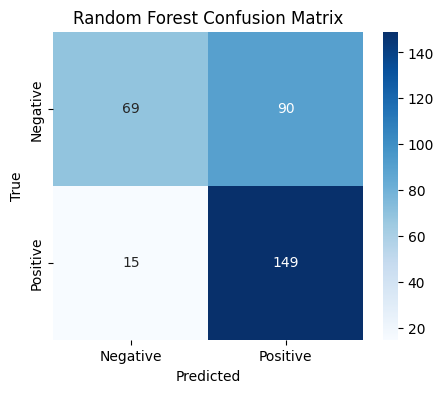

✅ Random Forest Sentiment Model Ready!

🎬 DEMO: SEARCH AUR RECOMMENDATIONS

🔍 'batman begins' search kiya...
❌ Movie database mein nahi mili.

🎯 'The Dark Knight Rises' ke liye recommendations:
                             Title  Score
                   The Dark Knight 0.3331
Batman v Superman: Dawn of Justice 0.1394
                        Iron Man 3 0.0763
                      Spider-Man 2 0.0440
                     Shin Godzilla 0.0439
    Dawn of the Planet of the Apes 0.0421
       G.I. Joe: The Rise of Cobra 0.0418
                       Rush Hour 3 0.0416
                     Green Lantern 0.0384
                  Star Trek Beyond 0.0383

🔥 Top 10 Popular Movies (Vote Count ke hisaab se):
                  title  vote_count                                                 genres
              Inception     13752.0 [Action, Thriller, ScienceFiction, Mystery, Adventure]
        The Dark Knight     12002.0                       [Drama, Action, Crime, Thriller]
                 Av

KeyboardInterrupt: Interrupted by user

In [ ]:
# ============================================================
# CELL 3: RECOMMENDER + RANDOM FOREST TRAIN + INTERACTIVE LOOP
# ============================================================

!pip install -q scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split # Ensure import is here if not global

# -------------------- 1. TF‑IDF Movie Recommender --------------------
print("\n" + "="*60)
print("🔧 TF‑IDF RECOMMENDATION ENGINE BAN RAHA HAI...")
print("="*60)

tfidf_movies = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_movies.fit_transform(new_df['tags'])
similarity = cosine_similarity(tfidf_matrix)

def get_recommendations(movie_title, n=10):
    exact_match = new_df[new_df['title'].str.lower() == movie_title.lower()]
    if not exact_match.empty:
        movie_index = exact_match.index[0]
        distances = similarity[movie_index]
        movies_list = sorted(list(enumerate(distances)), reverse=True,
                             key=lambda x: x[1])[1:n+1]
        recs = []
        for i in movies_list:
            recs.append({
                "Title": new_df.iloc[i[0]].title,
                "Score": round(i[1], 4),
                "Genres": new_df.iloc[i[0]].genres,
                "Vote_Count": new_df.iloc[i[0]].vote_count
            })
        return pd.DataFrame(recs)
    else:
        partial_matches = new_df[new_df['title'].str.lower()
                                 .str.contains(movie_title.lower(), na=False)]
        if not partial_matches.empty:
            suggestions = partial_matches['title'].tolist()[:5]
            return f"❓ Kya aapka matlab yeh tha: {', '.join(suggestions)}?"
        else:
            return "❌ Movie database mein nahi mili."

def get_popular_movies(n=10):
    popular = new_df.sort_values(by='vote_count', ascending=False).head(n)
    return popular[['title', 'vote_count', 'genres']].reset_index(drop=True)

print("✅ Recommender ready.")

# -------------------- 2. Random Forest Sentiment Training --------------------
print("\n" + "="*60)
print("🌲 RANDOM FOREST SENTIMENT MODEL TRAIN HO RAHA HAI (FROM SCRATCH)")
print("="*60)

# Prepare data for sentiment analysis
X = imdb_full['text']
y = imdb_full['label']

# Split data into training and testing sets (80% train, 20% test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training samples: {len(X_train_raw)}")
print(f"Test samples: {len(X_test_raw)}")

# TF-IDF vectorizer for sentiment
sent_vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X_train = sent_vectorizer.fit_transform(X_train_raw).toarray()
y_train = y_train.values # Convert to numpy array

X_test = sent_vectorizer.transform(X_test_raw).toarray()
y_test = y_test.values # Convert to numpy array

# Random Forest train karo
rf_sentiment = RandomForest(
    n_trees=10,               # 10 trees (aap 20-30 bhi kar sakte hain)
    max_depth=15,
    min_samples_split=10,
    max_features='sqrt'
)
rf_sentiment.fit(X_train, y_train)

# ---------- Accuracy Check ----------
y_pred = rf_sentiment.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n📊 Random Forest Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("✅ Random Forest Sentiment Model Ready!")

# Sentiment analysis function
def analyze_sentiment(text):
    vec = sent_vectorizer.transform([text]).toarray()
    pred = rf_sentiment.predict(vec)[0]
    proba = rf_sentiment.predict_proba(vec)[0]
    confidence = max(proba)

    if confidence < 0.6:
        return "Neutral 😐"
    return "Positive 😊" if pred == 1 else "Negative ☹️"

# -------------------- 3. Demo Search & Recommendations (Once) --------------------
print("\n" + "="*60)
print("🎬 DEMO: SEARCH AUR RECOMMENDATIONS")
print("="*60)

print("\n🔍 'batman begins' search kiya...")
print(get_recommendations('batman begins'))

print("\n🎯 'The Dark Knight Rises' ke liye recommendations:")
recs = get_recommendations('The Dark Knight Rises')
if isinstance(recs, pd.DataFrame):
    print(recs[['Title', 'Score']].to_string(index=False))
else:
    print(recs)

print("\n🔥 Top 10 Popular Movies (Vote Count ke hisaab se):")
print(get_popular_movies().to_string(index=False))

# -------------------- 4. Interactive Loop --------------------
print("\n" + "="*60)
print("🚀 INTERACTIVE SESSION SHURU HO RAHA HAI...")
print("="*60)

while True:
    print("\n" + "-"*50)
    user_input = input("🎥 Movie title likhein (ya 'sentiment' / 'exit'): ").strip()

    if user_input.lower() == 'exit':
        print("\n👋 Shukriya! Allah Hafiz.")
        break

    elif user_input.lower() == 'sentiment':
        print("\n💬 SENTIMENT ANALYSIS MODE (Random Forest)")
        review_text = input("✍️  Apna review likhein: ").strip()
        if review_text:
            sent = analyze_sentiment(review_text)
            print(f"\n📝 Review: {review_text[:150]}...")
            print(f"📊 Sentiment: {sent}")
            if "Positive" in sent:
                print("🌟 Yeh review POSITIVE hai.")
            elif "Negative" in sent:
                print("⚠️  Yeh review NEGATIVE hai.")
            else:
                print("🤔 Yeh review NEUTRAL hai.")
        else:
            print("⚠️  Koi review nahi likha.")
        continue

    elif user_input.lower() == 'popular':
        print("\n🔥 Top 10 Popular Movies:")
        print(get_popular_movies().to_string(index=False))
        continue

    # Movie recommendation
    result = get_recommendations(user_input)

    if isinstance(result, pd.DataFrame):
        print(f"\n🎯 '{user_input}' ke liye recommendations:\n")
        print(result[['Title', 'Score']].to_string(index=False))

        analyze_choice = input("\n📊 Kisi recommended movie ke liye sentiment analyze karna chahenge? (y/n): ").strip().lower()
        if analyze_choice == 'y':
            movie_to_analyze = input("🎬 Movie ka exact title likhein: ").strip()
            review_text = input(f"✍️  '{movie_to_analyze}' ke liye apna review likhein: ").strip()
            if review_text:
                sent = analyze_sentiment(review_text)
                print(f"\n📊 '{movie_to_analyze}' ke liye sentiment: {sent}")
            else:
                print("Koi review nahi diya.")
        print("\n" + "="*50)
    else:
        print(f"\n{result}")
        print("\n" + "="*50)

In [ ]:
# ============================================================
# CELL 4: SENTIMENT MODEL TEST KAREIN (USER INPUT)
# ============================================================

print("\n" + "="*60)
print("🧪 RANDOM FOREST SENTIMENT MODEL TESTING")
print("="*60)
print("Yahan aap apne reviews likh kar sentiment check kar sakte hain.")
print("'exit' likhne par test khatam ho jayega.\n")

while True:
    user_review = input("✍️  Review likhein (ya 'exit'): ").strip()

    if user_review.lower() == 'exit':
        print("\n👋 Sentiment testing khatam. Shukriya!")
        break

    if not user_review:
        print("⚠️  Kuch to likhein!\n")
        continue

    # Sentiment predict karo (yeh function Cell 3 mein defined hai)
    sent = analyze_sentiment(user_review)

    # Probability bhi nikal kar dikhao
    vec = sent_vectorizer.transform([user_review]).toarray()
    proba = rf_sentiment.predict_proba(vec)[0]

    print(f"\n📝 Review: {user_review[:150]}...")
    print(f"📊 Sentiment: {sent}")
    print(f"📈 Confidence: Negative={proba[0]:.2%}, Positive={proba[1]:.2%}")
    print("-" * 40 + "\n")


🧪 RANDOM FOREST SENTIMENT MODEL TESTING
Yahan aap apne reviews likh kar sentiment check kar sakte hain.
'exit' likhne par test khatam ho jayega.

✍️  Review likhein (ya 'exit'): BAD

📝 Review: BAD...
📊 Sentiment: Neutral 😐
📈 Confidence: Negative=50.00%, Positive=50.00%
----------------------------------------

✍️  Review likhein (ya 'exit'): VERY VERY BAD

📝 Review: VERY VERY BAD...
📊 Sentiment: Neutral 😐
📈 Confidence: Negative=50.00%, Positive=50.00%
----------------------------------------

✍️  Review likhein (ya 'exit'): GOOD

📝 Review: GOOD...
📊 Sentiment: Positive 😊
📈 Confidence: Negative=10.00%, Positive=90.00%
----------------------------------------

✍️  Review likhein (ya 'exit'): VERY GOOD

📝 Review: VERY GOOD...
📊 Sentiment: Positive 😊
📈 Confidence: Negative=10.00%, Positive=90.00%
----------------------------------------

